d:\ing elec u\noveno\tesis\TomaGrande\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[[31  0  1  0  0  0  0]
 [ 0  8  5 12  5  5  0]
 [ 0  7  4  7 21  3  0]
 [ 0 11  0 21  0  4  6]
 [ 2  0  1  1 31  0  8]
 [ 0 17  0  8  5  3 13]
 [ 0  3  4  4 16  1 12]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.17      0.23      0.20        35
           2       0.27      0.10      0.14        42
           3       0.40      0.50      0.44        42
           4       0.40      0.72      0.51        43
           5       0.19      0.07      0.10        46
           6       0.31      0.30      0.30        40

    accuracy                           0.39       280
   macro avg       0.38      0.41      0.38       280
weighted avg       0.36      0.39      0.36       280

Confusion matrix, without normalization
Normalized confusion matrix


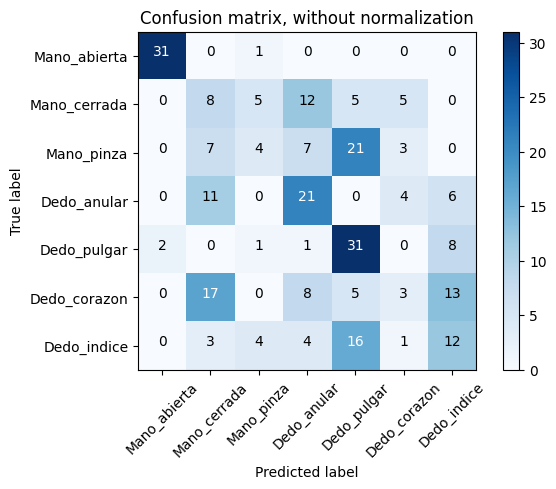

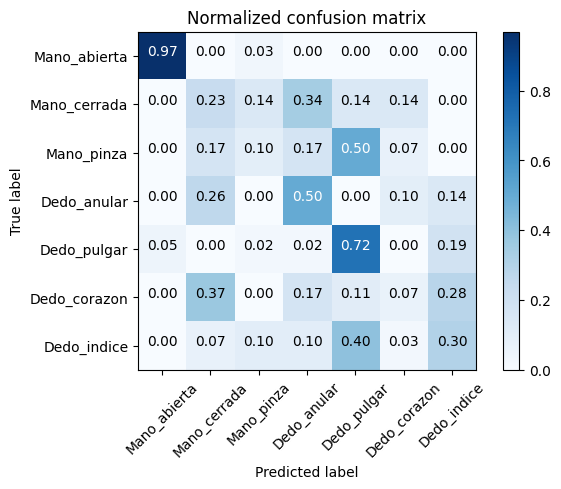

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000, multi_class='ovr')
logreg.fit(X_train, y_train)

# Hacer predicciones
y_pred = logreg.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[29  0  0  0  1  0  2]
 [ 0 13 11  6  3  1  1]
 [ 0  7 19  4 10  2  0]
 [ 0  4 12 23  0  2  1]
 [ 0  6 10  2 23  1  1]
 [ 0  7  2  6  0 29  2]
 [ 0  9  3  3  5  4 16]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.28      0.37      0.32        35
           2       0.33      0.45      0.38        42
           3       0.52      0.55      0.53        42
           4       0.55      0.53      0.54        43
           5       0.74      0.63      0.68        46
           6       0.70      0.40      0.51        40

    accuracy                           0.54       280
   macro avg       0.59      0.55      0.56       280
weighted avg       0.58      0.54      0.55       280

Confusion matrix, without normalization
Normalized confusion matrix


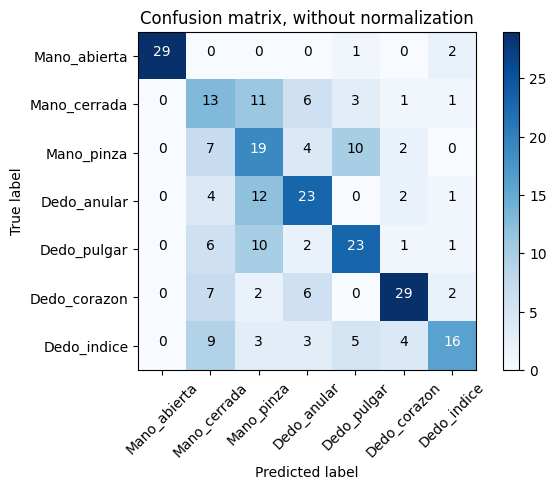

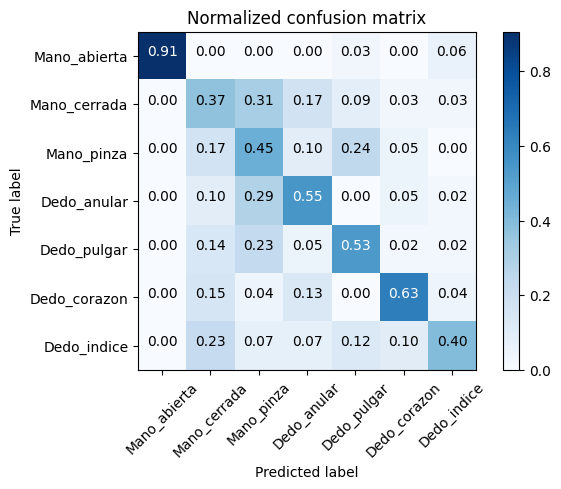

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Hacer predicciones
y_pred = knn.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[29  1  0  0  1  0  1]
 [ 2  9  7  6  2  4  5]
 [ 3  9 16  1 10  2  1]
 [ 1  2  7 20  2  4  6]
 [ 1  5 14  1 17  1  4]
 [ 2  4  3  8  1 24  4]
 [ 0  9  5  2  5  5 14]]
              precision    recall  f1-score   support

           0       0.76      0.91      0.83        32
           1       0.23      0.26      0.24        35
           2       0.31      0.38      0.34        42
           3       0.53      0.48      0.50        42
           4       0.45      0.40      0.42        43
           5       0.60      0.52      0.56        46
           6       0.40      0.35      0.37        40

    accuracy                           0.46       280
   macro avg       0.47      0.47      0.47       280
weighted avg       0.47      0.46      0.46       280

Confusion matrix, without normalization
Normalized confusion matrix


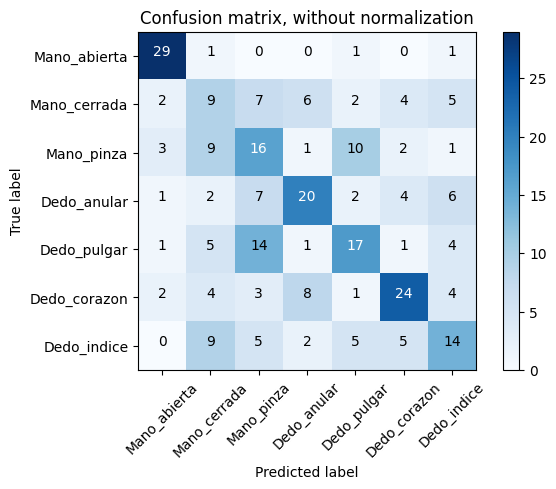

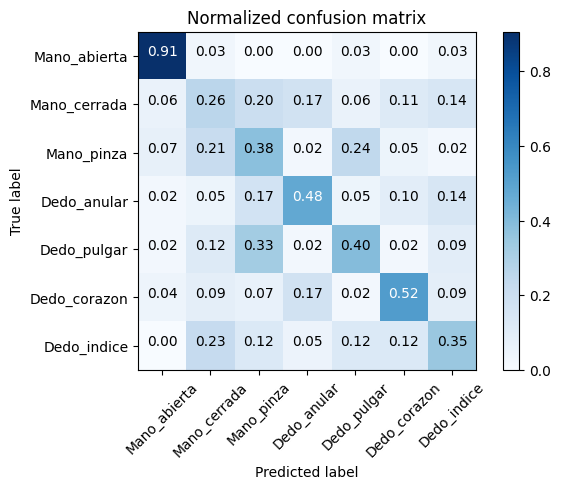

[[29  1  0  0  1  0  1]
 [ 2  9  7  6  2  4  5]
 [ 3  9 16  1 10  2  1]
 [ 1  2  7 20  2  4  6]
 [ 1  5 14  1 17  1  4]
 [ 2  4  3  8  1 24  4]
 [ 0  9  5  2  5  5 14]]
              precision    recall  f1-score   support

           0       0.76      0.91      0.83        32
           1       0.23      0.26      0.24        35
           2       0.31      0.38      0.34        42
           3       0.53      0.48      0.50        42
           4       0.45      0.40      0.42        43
           5       0.60      0.52      0.56        46
           6       0.40      0.35      0.37        40

    accuracy                           0.46       280
   macro avg       0.47      0.47      0.47       280
weighted avg       0.47      0.46      0.46       280



In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de árbol de decisiones
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Hacer predicciones
y_pred = tree.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()
# Hacer predicciones
y_pred = tree.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[29  1  0  0  2  0  0]
 [ 0  4  8 11  5  7  0]
 [ 0  2 10  4 15 11  0]
 [ 0  0  0 22  0 18  2]
 [ 0  1  6  7 27  0  2]
 [ 0  8  2  7  1 12 16]
 [ 0  2  7  5  8  3 15]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.22      0.11      0.15        35
           2       0.30      0.24      0.27        42
           3       0.39      0.52      0.45        42
           4       0.47      0.63      0.53        43
           5       0.24      0.26      0.25        46
           6       0.43      0.38      0.40        40

    accuracy                           0.42       280
   macro avg       0.44      0.44      0.43       280
weighted avg       0.42      0.42      0.41       280

Confusion matrix, without normalization
Normalized confusion matrix


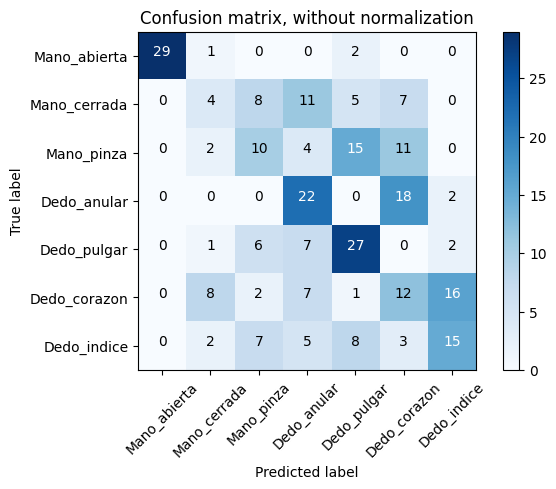

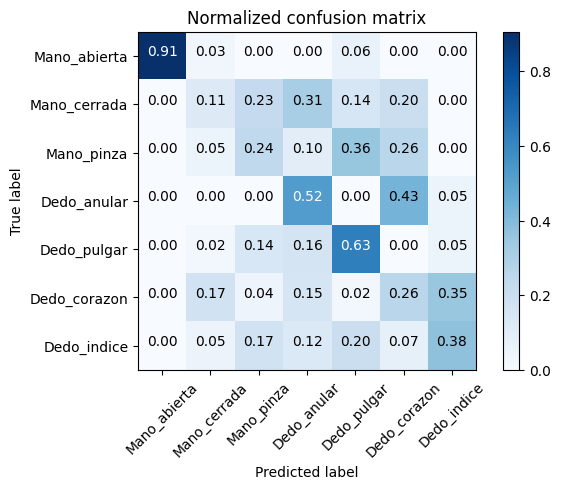

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de Máquina de Soporte Vectorial (SVM)
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Hacer predicciones
y_pred = svm.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()


Epoch 1/1000


d:\ing elec u\noveno\tesis\TomaGrande\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2853 - loss: 1.7484 - val_accuracy: 0.3536 - val_loss: 1.6439
Epoch 2/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3648 - loss: 1.5960 - val_accuracy: 0.3857 - val_loss: 1.5430
Epoch 3/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3640 - loss: 1.5276 - val_accuracy: 0.3964 - val_loss: 1.5048
Epoch 4/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4258 - loss: 1.4646 - val_accuracy: 0.4286 - val_loss: 1.4686
Epoch 5/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4553 - loss: 1.4045 - val_accuracy: 0.4000 - val_loss: 1.4337
Epoch 6/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4275 - loss: 1.4084 - val_accuracy: 0.4500 - val_loss: 1.3858
Epoch 7/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4552 - loss: 1.3372 - val_accuracy: 0.4750 - val_loss: 1.3588
Epoch 8/1000
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4499 - loss: 1.3283 - val_accuracy:

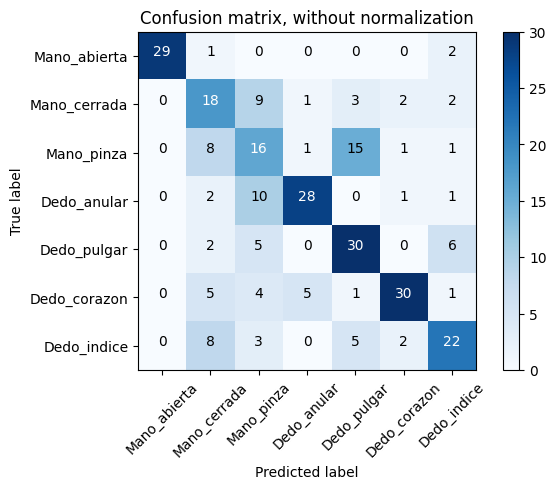

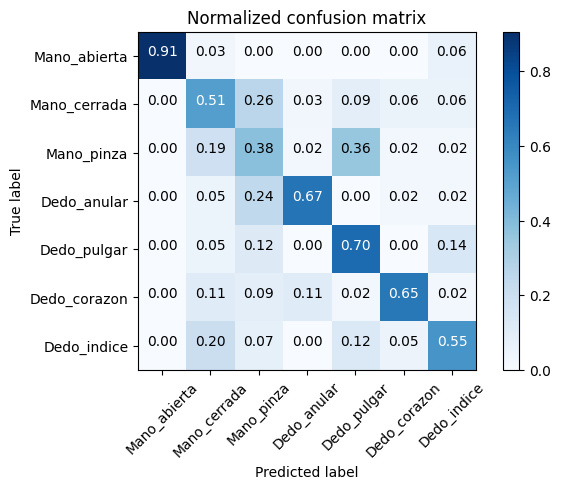

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertir las etiquetas en formato one-hot encoding
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

# Crear el modelo de red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))

# Compilar el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo
model.fit(X_train, y_train, epochs=1000, batch_size=10, validation_data=(X_test, y_test))

# Hacer predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluar el modelo
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_true, y_pred_classes)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()
